### Buid a basic ChatBot Langgraph(GRAPH API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

# Ensure the API keys are set in the environment
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "llama-3.1-8b-instant")

In [5]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [6]:
graph_builder = StateGraph(State)
## Adding Node
graph_builder.add_node("llmchatbot", chatbot)
## Adding Edge
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## Compile Graph
graph = graph_builder.compile()



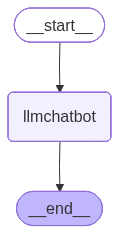

In [7]:
graph

In [8]:
response = graph.invoke({"messages":"Hi"})

In [9]:
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='b8a10a0d-9e14-4da6-af5b-b60e13f81087'),
  AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.007140255, 'completion_tokens_details': None, 'prompt_time': 0.001631237, 'prompt_tokens_details': None, 'queue_time': 0.156992042, 'total_time': 0.008771492}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5384-4211-7e71-90a7-9a6236437b16-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})]}

In [10]:
response['messages'][-1].content

'How can I assist you today?'

In [11]:
for event in graph.stream({"messages":"What is Agentic AI. Give answer in pointers"}):
    # print(event)
    for value in event.values():
        print(value["messages"][-1].content)


**Agentic AI**

Agentic AI refers to a type of artificial intelligence (AI) that possesses the ability to act independently, make decisions, and take actions in a manner that is goal-directed and self-aware. Here are some key pointers to understand Agentic AI:

### **Key Characteristics:**

1. **Autonomy**: Agentic AI systems operate independently, making decisions and taking actions without explicit human intervention.
2. **Goal-Directed Behavior**: Agentic AI systems have a clear purpose or goal that guides their actions and decisions.
3. **Self-Awareness**: Agentic AI systems possess some level of self-awareness, understanding their own capabilities, limitations, and context.
4. **Proactivity**: Agentic AI systems are proactive, taking initiative to achieve their goals and respond to changing circumstances.
5. **Learning and Adaptation**: Agentic AI systems can learn from experience and adapt to new situations, refining their decision-making and behavior over time.

### **Potential 

## Tool Calling LLM

In [6]:
from langchain_tavily import TavilySearch
from langchain_tavily import tavily_search

tool = TavilySearch(max_result=2)

In [13]:
tool.invoke("What is langchain")

{'query': 'What is langchain',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aws.amazon.com/what-is/langchain',
   'title': 'What is LangChain? - AWS',
   'content': 'LangChain is an open source framework for building applications based on large language models (LLMs). LLMs are large deep-learning models pre-trained on large amounts of data that can generate responses to user queries—for example, answering questions or creating images from text-based prompts. LangChain provides tools and abstractions to improve the customization, accuracy, and relevancy of the information the models generate. For example, developers can use LangChain components to build new prompt chains or customize existing templates. To do that, machine learning engineers must integrate the LLM with the organization’s internal data sources and apply *prompt engineering*—a practice where a data scientist refines inputs to a generative model with a specific structure and c

In [7]:
# custom function

def munliplty(a:int, b:int) -> int:
    """Multiply a and b
    Args:
    a(int): first int
    b(int): second int

    Return:
    int: output int
    """
    return a*b

In [8]:
tools = [tool,munliplty]

llm_with_tool = llm.bind_tools(tools)

llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x1114e38c0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1117a06e0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, a

In [16]:
## StateGraph
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode, tools_condition


class State(TypedDict):
    messages:Annotated[list,add_messages]

# Node defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Adding the edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools",END)


In [17]:
## Compile Graph
graph = builder.compile()

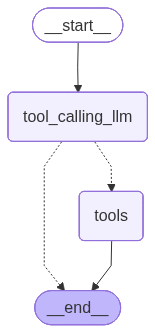

In [18]:
graph

In [34]:
response=graph.invoke({"messages":"What is stock price of Sbi"})

In [35]:
response["messages"][-1].content

'{"query": "Sbi stock price now", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://finance.yahoo.com/quote/8473.T", "title": "SBI Holdings, Inc. (8473.T) Stock Price, News, Quote & History", "content": "Find the latest SBI Holdings, Inc. (8473.T) stock quote, history, news and other vital information to help you with your stock trading and investing.", "score": 0.99982053, "raw_content": null}, {"url": "https://finance.yahoo.com/quote/SBI", "title": "Western Asset Intermediate Muni Fund Inc. (SBI) - Yahoo Finance", "content": "Find the latest Western Asset Intermediate Muni Fund Inc. (SBI) stock quote, history, news and other vital information to help you with your stock trading", "score": 0.99974483, "raw_content": null}, {"url": "https://finance.yahoo.com/quote/SBHGF", "title": "SBI Holdings, Inc. (SBHGF) Stock Price, News, Quote & History", "content": "Find the latest SBI Holdings, Inc. (SBHGF) stock quote, history, news and other vital informa

In [36]:
for m in response["messages"]:
    m.pretty_print()


================================ Human Message =================================

What is stock price of Sbi
================================== Ai Message ==================================
Tool Calls:
  tavily_search (5mrecr26n)
 Call ID: 5mrecr26n
  Args:
    query: Sbi stock price
    search_depth: advanced
    topic: finance
  tavily_search (j7qz3wt9w)
 Call ID: j7qz3wt9w
  Args:
    query: Sbi stock price today
    search_depth: advanced
    topic: finance
  tavily_search (99tkzt4f1)
 Call ID: 99tkzt4f1
  Args:
    query: Sbi stock price now
    search_depth: advanced
    topic: finance
================================= Tool Message =================================
Name: tavily_search

{"query": "Sbi stock price", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://finance.yahoo.com/quote/SBHGF", "title": "SBI Holdings, Inc. (SBHGF) Stock Price, News, Quote & History - Yahoo Finance", "content": "SBI Holdings, Inc. engages in investment busines

In [29]:
response=graph.invoke({"messages":"What is 5 multiply by 4 and then multiply by 6"})

In [30]:
for m in response["messages"]:
    m.pretty_print()


================================ Human Message =================================

What is 5 multiply by 4 and then multiply by 6
================================== Ai Message ==================================
Tool Calls:
  munliplty (htd2r1j55)
 Call ID: htd2r1j55
  Args:
    a: 5
    b: 4
  munliplty (747tgnt7m)
 Call ID: 747tgnt7m
  Args:
    a: 20
    b: 6
================================= Tool Message =================================
Name: munliplty

20
================================= Tool Message =================================
Name: munliplty

120


## React Arcitecture

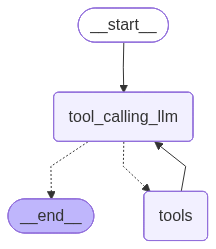

In [39]:
## StateGraph
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode, tools_condition


class State(TypedDict):
    messages:Annotated[list,add_messages]

# Node defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Adding the edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## Compile Graph
graph = builder.compile()

graph

In [40]:
response=graph.invoke({"messages":"What is stock price of Sbi"})

In [41]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is stock price of Sbi
================================== Ai Message ==================================
Tool Calls:
  tavily_search (j4hb6adzd)
 Call ID: j4hb6adzd
  Args:
    query: SBI stock price
    topic: finance
================================= Tool Message =================================
Name: tavily_search

{"query": "SBI stock price", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://finance.yahoo.com/quote/SBILIFE.NS/history", "title": "SBI Life Insurance Company Limited (SBILIFE.NS) - Yahoo Finance", "content": "SBI Life Insurance Company Limited (SBILIFE.NS) ; May 22, 2026, 1,872.00, 1,893.00 ; May 21, 2026, 1,869.90, 1,876.40 ; May 20, 2026, 1,860.00, 1,882.40 ; May 19,", "score": 0.826278, "raw_content": null}, {"url": "https://finance.yahoo.com/quote/SBIN.NS/history", "title": "State Bank of India (SBIN.NS) Stock Historical Prices & Data - Yahoo 

In [44]:
response=graph.invoke({"messages":"What is 5 multiply by 4 and then thr result multiply by 6"})

In [45]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiply by 4 and then thr result multiply by 6
================================== Ai Message ==================================
Tool Calls:
  munliplty (hff00bn7h)
 Call ID: hff00bn7h
  Args:
    a: 5
    b: 4
  munliplty (ch78t7wsq)
 Call ID: ch78t7wsq
  Args:
    a: 20
    b: 6
================================= Tool Message =================================
Name: munliplty

20
================================= Tool Message =================================
Name: munliplty

120
================================== Ai Message ==================================

The final answer is 120.


# Adding Memory In Agentic Graph

In [47]:
response=graph.invoke({"messages":"Hello my name is Sumit"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Sumit
================================== Ai Message ==================================

Hello Sumit, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [49]:
response=graph.invoke({"messages":"What is my name?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have any information about your name. I'm a large language model, I don't have the ability to know or remember personal information about individual users. Each time you interact with me, it's a new conversation and I don't retain any information from previous conversations.


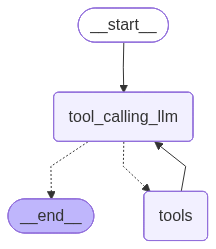

In [9]:
## StateGraph
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

class State(TypedDict):
    messages:Annotated[list,add_messages]

# Node defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Adding the edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## Compile Graph
graph = builder.compile(checkpointer=memory)

graph

In [10]:
config = {"configurable":{"thread_id": "1"}}

In [12]:
response=graph.invoke({"messages":"Hi my name is Sumit"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Sumit', additional_kwargs={}, response_metadata={}, id='5547e21d-d595-45a1-a173-e378809487d0'),
  AIMessage(content='Nice to meet you Sumit. What can I assist you with today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 1788, 'total_tokens': 1804, 'completion_time': 0.02973374, 'completion_tokens_details': None, 'prompt_time': 0.756556225, 'prompt_tokens_details': None, 'queue_time': 0.183196593, 'total_time': 0.786289965}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e53d7-418f-7372-964c-c096b4f89e34-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1788, 'output_tokens': 16, 'total_tokens': 1804}),
  HumanMessage(content='Hi my name is Sumit', additional_kwargs={}, response_metadata={}, id='dfc31e8c-6143-455a-81d

In [13]:
response["messages"][-1].content


"It looks like you've repeated your introduction. Would you like to ask a question or discuss something specific?"

In [14]:
response=graph.invoke({"messages":"Hi what is my name?"},config=config)

In [15]:
response["messages"][-1].content

'Your name is Sumit.'

In [16]:
response=graph.invoke({"messages":"Hi do you remember my name"},config=config)

In [17]:
response["messages"][-1].content

'Your name is Sumit. I remember it from your previous introductions.'

# Streaming

In [19]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [20]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

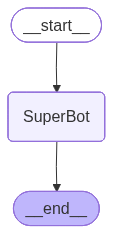

In [21]:
graph = StateGraph(State)

## node
graph.add_node("SuperBot",superbot)

## Add Edge
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)

graph_builder

In [22]:
config = {"configurable":{"thread_id":"1"}}

graph_builder.invoke({'messages':'Hi my name is sumit and I love codeing'}, config=config)

{'messages': [HumanMessage(content='Hi my name is sumit and I love codeing', additional_kwargs={}, response_metadata={}, id='dbd618a4-e449-4d6b-b085-00e23fa7006b'),
  AIMessage(content="Nice to meet you Sumit. It's great to hear that you love coding. What kind of coding do you enjoy the most? Are you into web development, mobile app development, or perhaps artificial intelligence and machine learning?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 46, 'total_tokens': 92, 'completion_time': 0.056926629, 'completion_tokens_details': None, 'prompt_time': 0.003112558, 'prompt_tokens_details': None, 'queue_time': 0.060120992, 'total_time': 0.060039187}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e53e1-5f9c-7a01-822f-23e78f7ef1b4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input

## Streaming

### Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

### Additional parameters in streaming modes for graph state

- values : This streams the full state of the graph after each node is called.
- updates : This streams updates to the state of the graph after each node is called.

In [24]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Nice to meet you, Krish. Cricket is a fantastic sport. Which team or player is your favorite in cricket? Or do you have a favorite format of the game, like Test cricket, One-Day Internationals (ODIs), or Twenty20 (T20)?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 45, 'total_tokens': 100, 'completion_time': 0.07835496, 'completion_tokens_details': None, 'prompt_time': 0.00298053, 'prompt_tokens_details': None, 'queue_time': 0.05534683, 'total_time': 0.08133549}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e53e6-1b89-7e53-b366-4721713caa5d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 55, 'total_tokens': 100})]}}


In [25]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='7319893f-6fbb-4cd5-9c63-55d6a2a93666'), AIMessage(content='Nice to meet you, Krish. Cricket is a fantastic sport. Which team or player is your favorite in cricket? Or do you have a favorite format of the game, like Test cricket, One-Day Internationals (ODIs), or Twenty20 (T20)?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 45, 'total_tokens': 100, 'completion_time': 0.07835496, 'completion_tokens_details': None, 'prompt_time': 0.00298053, 'prompt_tokens_details': None, 'queue_time': 0.05534683, 'total_time': 0.08133549}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e53e6-1b89-7e53-b366-4721713caa5d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tok

In [26]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Sumit And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Nice to meet you Sumit. Cricket is a popular sport, especially in India and other parts of the world. Which aspect of cricket do you enjoy the most - batting, bowling, fielding, or following the game as a spectator? Are you a fan of any particular team or player?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 46, 'total_tokens': 106, 'completion_time': 0.178232971, 'completion_tokens_details': None, 'prompt_time': 0.006602986, 'prompt_tokens_details': None, 'queue_time': 0.056592254, 'total_time': 0.184835957}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e53e7-a580-7cf2-ab0e-b30d930cd244-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 60, 'total_tokens': 106})]}}


In [27]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Sumit And I like cricket', additional_kwargs={}, response_metadata={}, id='c070e497-d0e3-4775-b776-c126c1680921'), AIMessage(content='Nice to meet you Sumit. Cricket is a popular sport, especially in India and other parts of the world. Which aspect of cricket do you enjoy the most - batting, bowling, fielding, or following the game as a spectator? Are you a fan of any particular team or player?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 46, 'total_tokens': 106, 'completion_time': 0.178232971, 'completion_tokens_details': None, 'prompt_time': 0.006602986, 'prompt_tokens_details': None, 'queue_time': 0.056592254, 'total_time': 0.184835957}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e53e7-a580-7cf2-ab0e-b30d930cd244-0', tool_calls=[], i

In [28]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e53eb-04ca-7a01-9cec-354c92ba8c1f', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='93490ae4-1498-4795-8aeb-5934b5ab26c7')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019e53eb-04d0-7173-b638-ea0ea5c3651d', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:dffbee54-62fa-0c9b-f783-b44e44b68f65'}, 'parent_ids': ['019e53eb-04ca-7a01-9cec-354c92ba8c1f']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':